In [13]:
import allel
print("allel:",allel.__version__)
import numpy as np
import scipy as sp
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd
print("pandas:",pd.__version__)

import tabix
import random

from math import isnan, isfinite

allel: 1.3.5
numpy: 1.21.6
pandas: 2.0.3


In [2]:
from plotnine import *

In [3]:
vcffile='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr1.vcf.gz'
ldfile='LDwins_all.txt'
metafile='resources/meta_Aaeg1kg_spp.txt'
invfile='resources/lostruct_inversions_table.txt'

chrtx={1:"NC_035107.1",2:"NC_035108.1",3:"NC_035109.1"}

In [4]:
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')
invs = pd.read_csv(invfile, sep='\t')


In [5]:
callsfile = "./invs_chr{}_inv_calls.txt"
namereplace = dict(zip([x.replace("X","") for x in invs['call_id']],invs['inv_name']))

allinvfreqs = None
for chrom in [1,2]:
    invcalls = pd.read_csv(callsfile.format(chrom),sep="\t").rename(columns=namereplace)
    for inv in invs['inv_name'][invs['chr']==chrom]:
        invfreq = invcalls.groupby("country")[inv].mean().reset_index()
        invfreq[inv] = invfreq[inv]/2

        if allinvfreqs is None:
            allinvfreqs = invfreq
        else:
            allinvfreqs = allinvfreqs.merge(invfreq)
        
allinvfreqs

,country,1a,1b,1c,1d,1e,1f,1g,2a,2b,2c
0,Angola,0.192308,0.000000,0.115385,0.000000,0.000000,0.000000,0.307692,0.076923,0.346154,0.000000
1,Argentina,0.375000,0.000000,0.458333,0.291667,0.333333,0.000000,0.000000,0.166667,0.250000,0.000000
2,Australia,0.000000,0.000000,0.000000,0.318182,0.000000,0.000000,0.000000,0.409091,0.954545,0.000000
3,Brazil,0.004608,0.013825,0.016129,0.034562,0.126728,0.000000,0.036866,0.244240,0.781106,0.000000
4,BurkinaFaso,0.569444,0.000000,0.291667,0.166667,0.055556,0.000000,0.000000,0.000000,0.138889,0.055556
5,Cameroon,0.961538,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.461538,0.000000
6,Colombia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.666667,0.750000,0.000000
7,Dominica,0.000000,0.266667,0.000000,0.033333,0.233333,0.000000,0.000000,0.200000,0.900000,0.000000
8,Gabon,0.593750,0.000000,0.250000,0.093750,0.007812,0.000000,0.031250,0.000000,0.148438,0.000000
9,Ghana,0.400000,0.000000,0.212500,0.150000,0.062500,0.000000,0.000000,0.037500,0.162500,0.000000


In [6]:
r2tab = np.genfromtxt(ldfile,delimiter='\t',names=True,dtype=None,encoding='utf-8')
r2tab = r2tab[r2tab['r2']!='r2']

r2df = pd.DataFrame(r2tab)
r2df['r2'] = pd.to_numeric(r2df['r2'])
r2df['start'] = pd.to_numeric(r2df['start'])
r2df['end'] = pd.to_numeric(r2df['end'])
r2df['chrom'] = pd.to_numeric(r2df['chrom'])

In [7]:
#get mean r2 for colinnear regions
goodcolinear = np.array([True]*len(r2df))
invflank=1e6

for ii in range(0,len(invs['inv_name'])):
    inm = invs['inv_name'][ii]
    ichr = invs['chr'][ii]
    ist = invs['start'][ii]
    ien = invs['end'][ii]
    goodcolinear[np.logical_and(r2df['chrom']==ichr,
                                np.logical_and(r2df['start'] > (ist-invflank),
                                               r2df['end'] < (ien+invflank))
                               )] = False

r2dfcolin = r2df[goodcolinear]

In [8]:
#normalise r2 by normalisation factors
r2facts = pd.DataFrame(r2dfcolin['r2'].mean() / r2dfcolin.groupby("country")['r2'].mean()).reset_index().rename(columns={"r2":"r2fact"})
r2normdf = r2df.merge(r2facts)
r2normdf['r2norm'] = r2normdf['r2'] * r2normdf['r2fact']


In [9]:
#get mean normalised r2 in inverted regions
meaninvr2s = None
ii=0
plim = 0.01
for ii in range(0,len(invs['inv_name'])):
    inm = invs['inv_name'][ii]
    ichr = invs['chr'][ii]
    ist = invs['start'][ii]
    ien = invs['end'][ii]

    invr2s = r2normdf[np.logical_and(r2normdf['chrom']>=ichr,
                                  np.logical_and(r2normdf['start']>=ist, r2normdf['end']<=ien))]
    
    meaninvr2 = invr2s.groupby('country')['r2norm'].mean().reset_index().rename(columns={"r2norm":inm})
    if meaninvr2s is None:
        meaninvr2s = meaninvr2
    else:
        meaninvr2s = meaninvr2.merge(meaninvr2s,on='country')
meaninvr2s

,country,2c,2b,2a,1g,1f,1e,1d,1c,1b,1a
0,Angola,0.039910,0.052746,0.060308,0.050041,0.050754,0.049738,0.061576,0.054609,0.048424,0.045265
1,Argentina,0.038147,0.055563,0.057948,0.047486,0.052596,0.057715,0.074116,0.055516,0.048724,0.046727
2,Australia,0.044315,0.048651,0.061591,0.042415,0.047821,0.055431,0.067956,0.053205,0.043914,0.040833
3,Brazil,0.040570,0.057885,0.059770,0.049878,0.052759,0.057733,0.063689,0.048997,0.041314,0.038406
4,BurkinaFaso,0.041792,0.065295,0.079780,0.053075,0.054066,0.057219,0.074227,0.066143,0.048795,0.042131
5,Cameroon,0.042815,0.063328,0.074015,0.051839,0.049398,0.055044,0.060655,0.062055,0.054064,0.042180
6,Dominica,0.034348,0.054209,0.060723,0.044845,0.049637,0.052731,0.058856,0.055758,0.052915,0.041313
7,Gabon,0.039247,0.055164,0.077707,0.047081,0.051086,0.056269,0.066580,0.062565,0.052466,0.042003
8,Ghana,0.043042,0.058325,0.072019,0.051210,0.052771,0.054058,0.070067,0.066908,0.052250,0.042060
9,Kenya,0.037866,0.057759,0.072938,0.050119,0.053569,0.054860,0.068851,0.066117,0.056405,0.041101


In [10]:
invfr2tab = meaninvr2s.melt(id_vars="country",var_name="inv_name",value_name="r2")
invfr2tab = invfr2tab.merge(allinvfreqs.melt(id_vars="country",var_name="inv_name",value_name="f"))
invfr2tab.loc[invfr2tab["f"]>0.5,"f"] = 1 - invfr2tab.loc[invfr2tab["f"]>0.5,"f"]

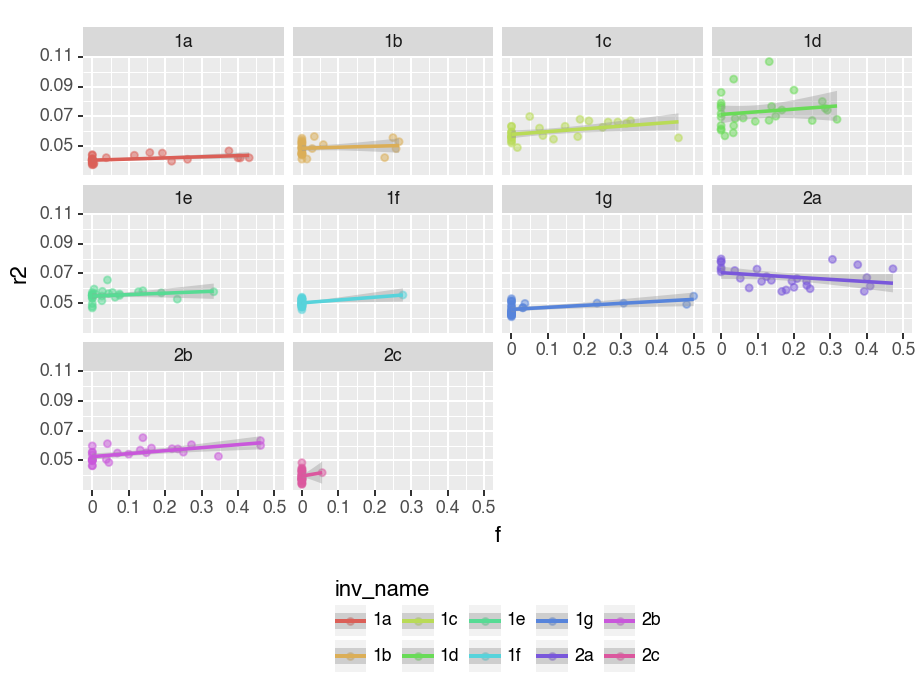

In [11]:
p = ggplot(invfr2tab,aes(x='f',y='r2',color="inv_name")) + \
  geom_point(alpha=0.5) + \
  geom_smooth(method="lm") + \
  facet_wrap("inv_name") +\
  theme(legend_position="bottom") 
print(p)


In [12]:
#get mean normalised r2 in inverted regions
blockinvr2s = None
ii=0
plim = 0.01
for ii in range(0,len(invs['inv_name'])):
    inm = invs['inv_name'][ii]
    ichr = invs['chr'][ii]
    ist = invs['start'][ii]
    ien = invs['end'][ii]

    invr2s = r2normdf[np.logical_and(r2normdf['chrom']>=ichr,
                                  np.logical_and(r2normdf['start']>=ist, r2normdf['end']<=ien))]
    
    blockr2norm = pd.DataFrame({"inv_name":[inm] * len(invr2s['country']),
                            "country":invr2s['country'],
                            "r2":invr2s['r2norm']})
    if blockinvr2s is None:
        blockinvr2s = blockr2norm
    else:
        blockinvr2s = blockinvr2s.append(blockr2norm)
blockinvr2s = blockinvr2s.merge(allinvfreqs.melt(id_vars="country",var_name="inv_name",value_name="f"))
blockinvr2s = blockinvr2s[blockinvr2s['r2']<=1]
blockinvr2s

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
p = ggplot(blockinvr2s,aes(x='r2',color="inv_name")) + \
  geom_density(alpha=0.5) + \
  theme(legend_position="right") +\
  xlim([0,0.2])
print(p)


In [ ]:
p = ggplot(blockinvr2s,aes(x='f',y='r2',color="inv_name")) + \
  geom_point(alpha=0.5) + \
  geom_smooth(method="lm",color="black") + \
  facet_wrap("inv_name") +\
  theme(legend_position="bottom") 
print(p)


In [ ]:
minf = 0.02
invfr2tab['hasinv'] = invfr2tab['f'] > minf
invfr2tab.loc[np.logical_and(invfr2tab['f'] > 0,invfr2tab['f'] < minf),"hasinv"] = np.nan 
invfr2tab['hasinv'] = invfr2tab['hasinv'].astype(str)
invfr2tab['group'] = invfr2tab[['hasinv','inv_name']].agg("_".join,axis=1)

In [ ]:
highers = []
pvals = []
labels = []

for invname in invs['inv_name']:
    r2inv = invfr2tab[np.logical_and(invfr2tab['inv_name'] == invname,invfr2tab['hasinv']=="True")]['r2']
    r2col = invfr2tab[np.logical_and(invfr2tab['inv_name'] == invname,invfr2tab['hasinv']=="False")]['r2']

    higher = np.mean(r2inv) > np.mean(r2col)
    test = sp.stats.ttest_ind(r2col,r2inv)
    
    if(higher and test.pvalue<0.01): label="**"
    elif (higher and test.pvalue<0.05): label="*"
    elif (higher and np.isnan(test.pvalue)): label="-"
    elif (higher): label=""
    else: label="-"
    
    highers.append(higher)
    pvals.append(test.pvalue)
    labels.append(label)
    
meanldtests = pd.DataFrame({"inv_name":invs['inv_name'],
             "mhigher":highers,
             "mpval":pvals,
             "mlabel":labels})

meanldtests

In [ ]:
p = ggplot(invfr2tab[invfr2tab['hasinv']!="nan"],aes(x='inv_name',y='r2',color="hasinv",group="group")) + \
  geom_boxplot() + \
  geom_text(aes(x="inv_name",label="labels"),meanldtests,y=0.02,inherit_aes=False) +\
  theme(legend_position="right") +\
  ylim([0,0.12])
print(p)


In [ ]:
minf = 0.02
blockinvr2s['hasinv'] = blockinvr2s['f'] > minf
blockinvr2s.loc[np.logical_and(blockinvr2s['f'] > 0,blockinvr2s['f'] < minf),"hasinv"] = np.nan 
blockinvr2s['hasinv'] = blockinvr2s['hasinv'].astype(str)
blockinvr2s['group'] = blockinvr2s[['hasinv','inv_name']].agg("_".join,axis=1)

highers = []
pvals = []
labels = []

for invname in invs['inv_name']:
    r2inv = blockinvr2s[np.logical_and(blockinvr2s['inv_name'] == invname,blockinvr2s['hasinv']=="True")]['r2']
    r2col = blockinvr2s[np.logical_and(blockinvr2s['inv_name'] == invname,blockinvr2s['hasinv']=="False")]['r2']

    higher = np.mean(r2inv) > np.mean(r2col)
    test = sp.stats.ttest_ind(r2col,r2inv)
    
    if(higher and test.pvalue<0.01): label="\u2020\u2020"
    elif (higher and test.pvalue<0.05): label="\u2020"
    elif (higher and np.isnan(test.pvalue)): label="-"
    elif (higher): label=""
    else: label=""
    
    highers.append(higher)
    pvals.append(test.pvalue)
    labels.append(label)
    
blockldtests = pd.DataFrame({"inv_name":invs['inv_name'],
             "bhigher":highers,
             "bpval":pvals,
             "blabel":labels})

blockldtests

In [ ]:
p = ggplot(blockinvr2s[blockinvr2s['hasinv']!="nan"],aes(x='inv_name',y='r2',color="hasinv",group="group")) + \
  geom_boxplot() + \
  geom_text(aes(x="inv_name",label="blabel"),blockldtests,y=0.01,inherit_aes=False) +\
  theme(legend_position="right") +\
  ylim([0,0.12])
print(p)


In [ ]:
p = ggplot(invfr2tab[invfr2tab['hasinv']!="nan"],aes(x='inv_name',y='r2',color="hasinv",group="group")) + \
  geom_boxplot() + \
  geom_text(aes(x="inv_name",label="mlabel"),data=meanldtests,y=0.02,inherit_aes=False) +\
  geom_text(aes(x="inv_name",label="blabel"),data=blockldtests,y=0.01,inherit_aes=False) +\
  theme(legend_position="right") +\
  ylim([0,0.12])
print(p)


In [ ]:
ldtests = meanldtests.merge(blockldtests)
ldtests['label']=""

In [ ]:
msig = np.logical_and(ldtests['mhigher'], ldtests['mpval']<0.05)
mnsig = np.logical_not(msig)
ldtests.loc[msig,'label'] = ldtests['mlabel'].loc[msig]
ldtests.loc[mnsig,'label'] = ldtests['blabel'].loc[mnsig]

In [ ]:
p = ggplot(invfr2tab[invfr2tab['hasinv']!="nan"],aes(x='inv_name',y='r2',color="hasinv",group="group")) + \
  geom_boxplot() + \
  geom_text(aes(x="inv_name",label="label"),data=ldtests,y=0.02,inherit_aes=False) +\
  scale_colour_manual(values=["green","red"],labels=["no inversion","inversion"]) +\
  theme(legend_position="right",legend_title=element_blank(),
        axis_title_x=element_blank()) +\
  labs(title="inversion elevated LD t-tests", 
       caption='** p < 0.01; * P < 0.05; †† p < 0.01; † p < 0.05') +\
  ylim([0,0.12])
print(p)
ggsave(plot=p, width=300,height=125,units='mm', filename='inversion_elevated_ld_tests.png', dpi=400)


In [ ]:
ldtests
